In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import kagglehub
from pathlib import Path

c:\Users\User\Desktop\Nova pasta (2)\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Carregamos todas as Tabelas

local_path_str = kagglehub.dataset_download("rivalytics/saas-subscription-and-churn-analytics-dataset")
DATA_PATH = Path(local_path_str)

datasets = {
        "accounts": pd.read_csv(DATA_PATH / "ravenstack_accounts.csv"),
        "subscriptions": pd.read_csv(DATA_PATH / "ravenstack_subscriptions.csv"),
        "feature_usage": pd.read_csv(DATA_PATH / "ravenstack_feature_usage.csv"),
        "support_tickets": pd.read_csv(DATA_PATH / "ravenstack_support_tickets.csv"),
        "churn_events": pd.read_csv(DATA_PATH / "ravenstack_churn_events.csv")
    }

In [3]:
# Visualização das Tabelas

accounts_df = datasets["accounts"]
subscriptions_df = datasets["subscriptions"]
feature_usage_df = datasets["feature_usage"]
support_tickets_df = datasets["support_tickets"]
churn_events_df = datasets["churn_events"]

def show_all_tables():
    
    print("Accounts DataFrame:")
    display(accounts_df.head())

    print("Subscriptions DataFrame:")
    display(subscriptions_df.head())

    print("Feature Usage DataFrame:")
    display(feature_usage_df.head())

    print("Support Tickets DataFrame:")
    display(support_tickets_df.head())

    print("Churn Events DataFrame:")
    display(churn_events_df.head())

show_all_tables()

Accounts DataFrame:


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


Subscriptions DataFrame:


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


Feature Usage DataFrame:


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


Support Tickets DataFrame:


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


Churn Events DataFrame:


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [4]:
# Visao Geral dos datasets

dataset_overview = pd.DataFrame({
    'Table': ['Accounts', 'Subscriptions', 'Feature Usage', 'Support Tickets', 'Churn Events'],
    'Rows': [accounts_df.shape[0], subscriptions_df.shape[0], feature_usage_df.shape[0], support_tickets_df.shape[0], churn_events_df.shape[0]],
    'Columns': [accounts_df.shape[1], subscriptions_df.shape[1], feature_usage_df.shape[1], support_tickets_df.shape[1], churn_events_df.shape[1]]
})

display(dataset_overview)

,Table,Rows,Columns
0,Accounts,500,10
1,Subscriptions,5000,14
2,Feature Usage,25000,8
3,Support Tickets,2000,9
4,Churn Events,600,9


In [5]:
# Calcula o total de nulos em porcentagem

sumario_valores_nulos = []

for nome , tabela in datasets.items():
    total_linhas = len(tabela)
    contagem_nulos = tabela.isnull().sum()
    percentual_nulos = (tabela.isnull().mean() * 100)

    for coluna in tabela.columns:
        if(contagem_nulos[coluna] > 0):

            sumario_valores_nulos.append({
                'Tabela': nome,
                'Coluna': coluna,
                'Valores_nulos': contagem_nulos[coluna],
                'Total_linhas': total_linhas,
                'Porcentagem_nulos': round(percentual_nulos[coluna],2)
            })

nulos_df = pd.DataFrame(sumario_valores_nulos)

display(nulos_df)

,Tabela,Coluna,Valores_nulos,Total_linhas,Porcentagem_nulos
0,subscriptions,end_date,4514,5000,90.28
1,support_tickets,satisfaction_score,825,2000,41.25
2,churn_events,feedback_text,148,600,24.67


In [6]:
# Verificando a integridade dos relacionamentos das tabelas

checkagem_relacionamentos = pd.DataFrame({
    "Checkagem_Validacao":[
        "Subscriptions → Accounts",
        "Feature Usage → Subscriptions",
        "Support Tickets → Accounts",
        "Churn Events → Accounts"
    ],
    "Registros_Invalidos":[
        len(subscriptions_df[~subscriptions_df["account_id"].isin(accounts_df["account_id"])]),
        len(feature_usage_df[~feature_usage_df["subscription_id"].isin(feature_usage_df["subscription_id"])]),
        len(support_tickets_df[~support_tickets_df["account_id"].isin(support_tickets_df["account_id"])]),
        len(churn_events_df[~churn_events_df["account_id"].isin(churn_events_df["account_id"])]),
    ]
})

display(checkagem_relacionamentos)


,Checkagem_Validacao,Registros_Invalidos
0,Subscriptions → Accounts,0
1,Feature Usage → Subscriptions,0
2,Support Tickets → Accounts,0
3,Churn Events → Accounts,0


In [7]:
# Validação de Registros Duplicados

checkagem_duplicadas = pd.DataFrame({
    "Tabela": list(datasets.keys()),
    "Linhas_duplicadas": [
        tabela.duplicated().sum()
        for tabela in datasets.values()
    ],
    "porcentagem_duplicadas": [
        round(tabela.duplicated().mean() * 100 , 2)
        for tabela in datasets.values()
    ]
})

display(checkagem_duplicadas)

,Tabela,Linhas_duplicadas,porcentagem_duplicadas
0,accounts,0,0.0
1,subscriptions,0,0.0
2,feature_usage,0,0.0
3,support_tickets,0,0.0
4,churn_events,0,0.0


In [8]:
# Aplicando conversao de data nas colunas que são necessárias
date_columns = ['signup_date', 'start_date','end_date','usage_date','submitted_at','closed_at','churn_date']

for nome, df in datasets.items():
    colunas_existentes = [col for col in date_columns if col in df.columns]
    if colunas_existentes:
        datasets[nome][colunas_existentes] = df[colunas_existentes].apply(pd.to_datetime, errors="coerce")

## Análise de Churn

In [9]:
churn_rate = accounts_df['churn_flag'].value_counts(normalize=True)*100
display(f"Taxa de Churn Geral (Accounts): {churn_rate[True]:.2f}%")

churn_por_industria = (accounts_df.groupby('industry')['churn_flag'].mean().sort_values(ascending=False) * 100).round(2)
display(churn_por_industria)

'Taxa de Churn Geral (Accounts): 22.00%'

industry
DevTools         30.97
FinTech          22.32
HealthTech       21.88
EdTech           16.46
Cybersecurity    16.00
Name: churn_flag, dtype: float64

In [10]:
mrr_total_ativo = subscriptions_df[subscriptions_df['churn_flag'] == False]['mrr_amount'].sum()
mrr_total_perdido = subscriptions_df[subscriptions_df['churn_flag'] == True]['mrr_amount'].sum()

mrr_churn_rate = (mrr_total_perdido / (mrr_total_ativo + mrr_total_perdido)) * 100
print(f"Churn de Receita (MRR): {mrr_churn_rate:.2f}%")

Churn de Receita (MRR): 10.40%


In [11]:
# Principais motivos do Churn
motivos = churn_events_df['reason_code'].value_counts(normalize=True) * 100
motivos_format = motivos.map("{:.2f}%".format)

motivos_qtd =  churn_events_df.groupby('reason_code')['account_id'].count()

tabela_motivos = pd.DataFrame({
    "motivo_%": motivos_format,
    "quantidade": motivos_qtd
})

display(tabela_motivos.sort_values(by="quantidade", ascending=False).reset_index())

,reason_code,motivo_%,quantidade
0,features,19.00%,114
1,budget,17.33%,104
2,support,17.33%,104
3,unknown,15.83%,95
4,competitor,15.33%,92
5,pricing,15.17%,91


In [12]:
# 1. Conta quantos eventos de churn cada conta possui
churn_por_cliente = (
    churn_events_df.groupby("account_id")["churn_event_id"]
    .count()
    .reset_index()
)
churn_por_cliente.columns = ["account_id", "total_cancelamentos"]
reincidentes = churn_por_cliente[churn_por_cliente["total_cancelamentos"] > 1]

print(f"Total de clientes únicos que deram churn: {len(churn_por_cliente)}")
print(f"Total de clientes que deram churn MAIS DE UMA VEZ: {len(reincidentes)}")

# 3. Exibe os top clientes recorrentes
display(
    reincidentes.sort_values(by="total_cancelamentos", ascending=False).head()
)

Total de clientes únicos que deram churn: 352
Total de clientes que deram churn MAIS DE UMA VEZ: 175


,account_id,total_cancelamentos
20,A-0a62f5,5
40,A-180abf,5
22,A-0baac2,4
82,A-37f969,4
24,A-0cc442,4


In [13]:

churn_por_cliente = (
    churn_events_df.groupby("account_id").size().reset_index(name="total_churns")
)
contas_reincidentes = churn_por_cliente[churn_por_cliente["total_churns"] > 1]

feedbacks_reincidentes = churn_events_df[
    churn_events_df["account_id"].isin(contas_reincidentes["account_id"])
].copy()

tabela_feedbacks = feedbacks_reincidentes[
    ["account_id", "churn_date", "reason_code", "feedback_text"]
].sort_values(by=["account_id", "churn_date"])

tabela_feedbacks_validos = tabela_feedbacks.dropna(subset=["feedback_text"])

display(tabela_feedbacks_validos.head())


,account_id,churn_date,reason_code,feedback_text
518,A-029f69,2024-10-31,competitor,switched to competitor
47,A-029f69,2024-12-14,competitor,too expensive
530,A-0354fe,2024-11-15,unknown,switched to competitor
128,A-0354fe,2024-11-26,support,switched to competitor
285,A-038089,2024-12-25,features,too expensive


,feedback_text,tamanho,porcentagem
0,too expensive,161,35.62%
1,missing features,155,34.29%
2,switched to competitor,136,30.09%


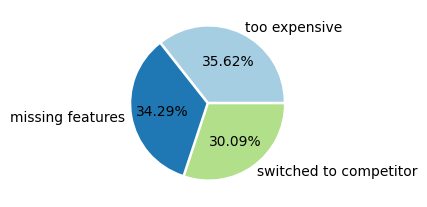

In [14]:
total_validos = len(churn_events_df.dropna(subset=["feedback_text"]))

frequencia_feedback = (
    churn_events_df.dropna(subset=["feedback_text"])
    .groupby("feedback_text")
    .agg(
        tamanho=("feedback_text", "count"),
        porcentagem=(
            "feedback_text",
            lambda x: (len(x) / total_validos) * 100,
        ),
    )
    .reset_index()
)

frequencia_feedback = frequencia_feedback.sort_values(
    by="tamanho", ascending=False
).reset_index(drop=True)

frequencia_feedback["porcentagem"] = frequencia_feedback["porcentagem"].map(
    "{:.2f}%".format
)

display(frequencia_feedback)

fig, axes = plt.subplots(figsize=(4,4))
axes.pie(
    frequencia_feedback['tamanho'],
    labels=frequencia_feedback['feedback_text'],
    autopct='%1.2f%%',
    colors=plt.cm.Paired.colors,
    explode=(0.02,0.02,0.02))

plt.tight_layout()
plt.show()

In [15]:
suporte_por_conta = support_tickets_df.groupby('account_id').agg(
    total_tickets=('ticket_id', 'count'),
    media_satisfacao=('satisfaction_score', 'mean'),
    media_tempo_resposta_min=('first_response_time_minutes', 'mean'),
    total_escalados=('escalation_flag', 'sum')
).reset_index()

df_analise_suporte = pd.merge(accounts_df[['account_id', 'churn_flag']], suporte_por_conta, on='account_id', how='left').sort_values(by="total_tickets", ascending=False)

display(df_analise_suporte[df_analise_suporte['churn_flag']== True].head(10))


display(df_analise_suporte.groupby('churn_flag').mean(numeric_only=True))

# Olhando somente para esses dados, vemos que o suporte é Cordial ( ganha notas boas ), porém nao resolve a demanda do cliente ( motivo de ser 17,33% de Churn)

,account_id,churn_flag,total_tickets,media_satisfacao,media_tempo_resposta_min,total_escalados
256,A-3ce5b8,True,10.0,3.714286,101.800000,0.0
185,A-139c3b,True,9.0,4.500000,66.111111,0.0
99,A-503d5a,True,9.0,4.000000,81.777778,0.0
436,A-34ea2f,True,8.0,3.800000,65.625000,0.0
280,A-443b7c,True,8.0,4.400000,49.000000,0.0
272,A-e4bf56,True,8.0,3.666667,111.500000,0.0
400,A-0f6450,True,8.0,3.833333,81.625000,1.0
79,A-9208f0,True,8.0,3.333333,59.750000,1.0
221,A-d922bf,True,7.0,3.333333,101.142857,1.0
299,A-7f6b86,True,7.0,3.666667,96.571429,0.0


,total_tickets,media_satisfacao,media_tempo_resposta_min,total_escalados
churn_flag,,,,
False,4.083333,3.953395,89.581916,0.184896
True,4.000000,4.002591,84.926947,0.222222


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,churn_flag
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False,A-e08cd3,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False,A-c7ffc2,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False,A-bbe56f,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False,A-7f29a7,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False,A-65a46c,False


,churn_flag,media_de_uso
0,False,453.44
1,True,76.30


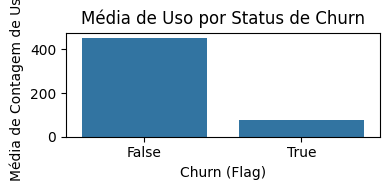

In [16]:
df_usage_complete = pd.merge(feature_usage_df, subscriptions_df[['subscription_id', 'account_id', 'churn_flag']], on='subscription_id', how='inner')
display(df_usage_complete.head())

uso_por_status = df_usage_complete.groupby(['churn_flag','account_id'])['usage_count'].sum().groupby('churn_flag').mean().reset_index(name='media_de_uso').round(2)
display(uso_por_status)

fig, ax = plt.subplots(figsize=(4,2))
sb.barplot(
    data=uso_por_status, 
    x='churn_flag', 
    y='media_de_uso'
    )

ax.set_title('Média de Uso por Status de Churn')
ax.set_xlabel('Churn (Flag)')
ax.set_ylabel('Média de Contagem de Uso')

plt.tight_layout()
plt.show()



In [17]:

churn_por_pais = accounts_df.groupby('country').agg(
    clientes_churn=('churn_flag','sum'),
    total=('churn_flag', 'count'),
    taxa_churn_pct=('churn_flag', 'mean')
).reset_index()

churn_por_pais['taxa_churn_pct'] = (churn_por_pais['taxa_churn_pct']*100).round(2)

display(churn_por_pais)

,country,clientes_churn,total,taxa_churn_pct
0,AU,4,32,12.50
1,CA,4,23,17.39
2,DE,8,25,32.00
3,FR,5,22,22.73
4,IN,10,49,20.41
5,UK,11,58,18.97
6,US,68,291,23.37


In [18]:
df_churn_true = accounts_df[accounts_df['churn_flag'] == True]
churn_plan_tier = (
        df_churn_true
        .groupby('plan_tier')['account_id']
        .agg(contagem='count')
        .reset_index()
    )

total_churn = churn_plan_tier['contagem'].sum()
churn_plan_tier['porcentagem'] = (churn_plan_tier['contagem'] / total_churn) * 100
churn_plan_tier = (
        churn_plan_tier
        .sort_values(by='contagem', ascending=False)
        .reset_index(drop=True)
    )

churn_plan_tier['porcentagem'] = churn_plan_tier['porcentagem'].map("{:.2f}%".format)

display(churn_plan_tier)

,plan_tier,contagem,porcentagem
0,Pro,39,35.45%
1,Basic,37,33.64%
2,Enterprise,34,30.91%


In [28]:
# Verificação de contas Trials que estão em churn

df_subscriptions_atual = (
        subscriptions_df
        .sort_values(by=['account_id', 'start_date']) # Garante a ordem cronológica
        .drop_duplicates(subset=['account_id'], keep='last')
    )
    
# 2. Fazemos o merge limpo: 1 linha por cliente na tabela de contas + 1 linha atual de assinatura
df_consolidado_real = pd.merge(
    accounts_df[['account_id', 'churn_flag']], 
    df_subscriptions_atual[['account_id', 'is_trial', 'plan_tier']], 
    on='account_id', 
    how='inner'
)

# 3. Agora sim, aplicamos o pipeline de agregação sem duplicidade
churn_trial_analysis = (
    df_consolidado_real
    .groupby(['churn_flag', 'is_trial'])['account_id']
    .agg(contagem='count')
    .reset_index()
)

# Cálculo da porcentagem real por grupo de Churn
churn_trial_analysis['porcentagem'] = (
    churn_trial_analysis['contagem'] / 
    churn_trial_analysis.groupby('churn_flag')['contagem'].transform('sum')
).round(4) * 100

display(churn_trial_analysis)


,churn_flag,is_trial,contagem,porcentagem
0,False,False,334,85.64
1,False,True,56,14.36
2,True,False,95,86.36
3,True,True,15,13.64


In [34]:
contas_que_foram_trial = subscriptions_df[subscriptions_df['is_trial'] == True]['account_id'].unique()

contas_pagas_atualmente = subscriptions_df[
        (subscriptions_df['is_trial'] == False) & 
        (subscriptions_df['plan_tier'] == 'Enterprise')
    ]['account_id'].unique()

contas_convertidas = set(contas_que_foram_trial).intersection(set(contas_pagas_atualmente))

accounts_df['status_jornada'] = 'Cliente Direto'
accounts_df.loc[accounts_df['account_id'].isin(contas_que_foram_trial), 'status_jornada'] = 'Ex-Trial (Cancelado/Retido)'
accounts_df.loc[accounts_df['account_id'].isin(contas_convertidas), 'status_jornada'] = 'Convertido para Enterprise'

display(accounts_df['status_jornada'].value_counts())

status_jornada
Convertido para Enterprise     380
Cliente Direto                  97
Ex-Trial (Cancelado/Retido)     23
Name: count, dtype: int64